<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/10_Neural_Learning_About_Edges_and_Corners_Intro_to_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10 Neural Learning About Edges and Corners


## Reproduksi Chapter 10 Grokking Deep Learning

Bab ini membahas dasar Convolutional Neural Network, operasi convolution, kernel, feature map, edge detection, serta implementasi menggunakan NumPy dari nol.


## Learning Objectives


1. Memahami keterbatasan fully connected network pada gambar.
2. Memahami local connectivity.
3. Memahami weight sharing.
4. Memahami convolution.
5. Memahami kernel dan filter.
6. Memahami feature map.
7. Memahami edge detection.
8. Mengimplementasikan convolution menggunakan NumPy.
9. Memahami hubungan CNN dengan computer vision modern.


## Mengapa CNN Dibutuhkan


Data gambar memiliki struktur spasial. Piksel yang berdekatan biasanya memiliki hubungan yang lebih kuat dibanding piksel yang berjauhan.

Jika gambar 224 x 224 diproses menggunakan fully connected layer, jumlah parameter menjadi sangat besar. CNN mengatasi masalah ini dengan memanfaatkan pola lokal dan penggunaan bobot yang sama pada berbagai posisi.


## Konsep Local Receptive Field


Neuron pada CNN hanya melihat sebagian kecil gambar. Area kecil ini disebut receptive field.

Pendekatan ini memungkinkan model mempelajari pola sederhana seperti garis, sudut, dan tekstur.


## Weight Sharing


CNN menggunakan kernel yang sama di seluruh gambar.

Keuntungan:
1. Parameter lebih sedikit.
2. Lebih efisien.
3. Pola dapat dikenali pada posisi berbeda.


## Kernel dan Filter


Kernel adalah matriks kecil yang digeser pada gambar.

Contoh kernel 3 x 3:

[1,0,-1]
[1,0,-1]
[1,0,-1]

Kernel ini sering digunakan untuk mendeteksi tepi vertikal.


## Operasi Convolution


Langkah convolution:

1. Tempatkan kernel pada area gambar.
2. Kalikan elemen yang bersesuaian.
3. Jumlahkan seluruh hasil.
4. Simpan ke feature map.
5. Geser kernel dan ulangi.


## Feature Map


Feature map adalah keluaran hasil convolution.

Feature map menonjolkan pola yang dicari oleh kernel tertentu.


## Edge Detection


Edge detection merupakan salah satu aplikasi awal convolution.

Tepi muncul ketika terjadi perubahan intensitas piksel yang signifikan.


## CNN dalam Computer Vision


Layer awal mempelajari garis dan tepi.

Layer menengah mempelajari bentuk sederhana.

Layer dalam mempelajari objek kompleks.


## Kesimpulan


CNN merupakan fondasi utama computer vision modern karena mampu mengekstraksi fitur lokal secara efisien menggunakan convolution dan weight sharing.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt


## Membuat Contoh Gambar Sederhana

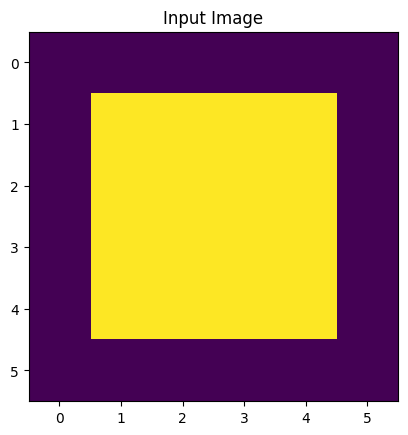

In [ ]:

image = np.array([
    [0,0,0,0,0,0],
    [0,1,1,1,1,0],
    [0,1,1,1,1,0],
    [0,1,1,1,1,0],
    [0,1,1,1,1,0],
    [0,0,0,0,0,0]
])

plt.imshow(image)
plt.title("Input Image")
plt.show()


## Implementasi Convolution dari Nol Menggunakan NumPy

In [ ]:

def convolution(image, kernel):

    h, w = image.shape
    kh, kw = kernel.shape

    out_h = h - kh + 1
    out_w = w - kw + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):

            region = image[i:i+kh, j:j+kw]

            output[i,j] = np.sum(region * kernel)

    return output


## Kernel Edge Vertikal

In [ ]:

vertical_kernel = np.array([
    [1,0,-1],
    [1,0,-1],
    [1,0,-1]
])

vertical_kernel


array([[ 1,  0, -1],
       [ 1,  0, -1],
       [ 1,  0, -1]])

In [ ]:

vertical_feature_map = convolution(image, vertical_kernel)

print(vertical_feature_map)


[[-2.  0.  0.  2.]
 [-3.  0.  0.  3.]
 [-3.  0.  0.  3.]
 [-2.  0.  0.  2.]]


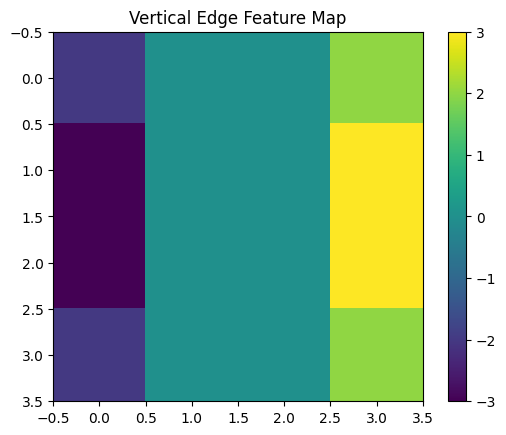

In [ ]:

plt.imshow(vertical_feature_map)
plt.title("Vertical Edge Feature Map")
plt.colorbar()
plt.show()


## Kernel Edge Horizontal

In [ ]:

horizontal_kernel = np.array([
    [1,1,1],
    [0,0,0],
    [-1,-1,-1]
])

horizontal_feature_map = convolution(image, horizontal_kernel)

print(horizontal_feature_map)


[[-2. -3. -3. -2.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 2.  3.  3.  2.]]


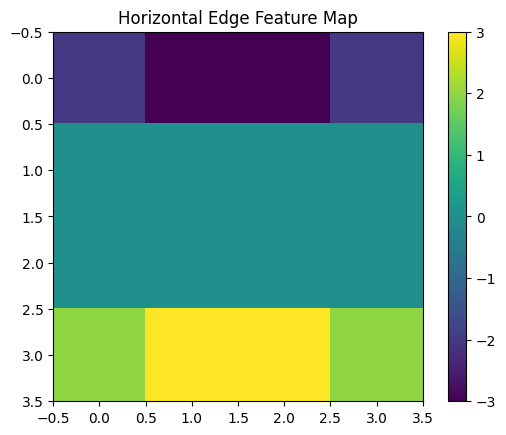

In [ ]:

plt.imshow(horizontal_feature_map)
plt.title("Horizontal Edge Feature Map")
plt.colorbar()
plt.show()


## Analisis Hasil Feature Map


Nilai besar pada feature map menunjukkan keberadaan pola yang sesuai dengan kernel.

Jika kernel dirancang untuk mendeteksi tepi vertikal maka area dengan perubahan vertikal akan menghasilkan aktivasi yang lebih besar.


## Multiple Filters

In [ ]:

kernels = [
    np.array([[1,0,-1],[1,0,-1],[1,0,-1]]),
    np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
]

for idx, kernel in enumerate(kernels):

    fmap = convolution(image, kernel)

    print("Filter", idx + 1)
    print(fmap)
    print()


Filter 1
[[-2.  0.  0.  2.]
 [-3.  0.  0.  3.]
 [-3.  0.  0.  3.]
 [-2.  0.  0.  2.]]

Filter 2
[[-2. -3. -3. -2.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 2.  3.  3.  2.]]



## Stride


Stride menentukan seberapa jauh kernel bergeser setiap langkah.

Stride lebih besar menghasilkan feature map yang lebih kecil dan komputasi lebih cepat.


In [ ]:

def convolution_stride(image, kernel, stride=1):

    h,w = image.shape
    kh,kw = kernel.shape

    out_h = ((h-kh)//stride)+1
    out_w = ((w-kw)//stride)+1

    output = np.zeros((out_h,out_w))

    row_out = 0

    for i in range(0,h-kh+1,stride):

        col_out = 0

        for j in range(0,w-kw+1,stride):

            region = image[i:i+kh,j:j+kw]

            output[row_out,col_out] = np.sum(region*kernel)

            col_out += 1

        row_out += 1

    return output


In [ ]:

feature_stride2 = convolution_stride(
    image,
    vertical_kernel,
    stride=2
)

print(feature_stride2)


[[-2.  0.]
 [-3.  0.]]


## Padding


Padding menambahkan piksel tambahan pada tepi gambar sehingga informasi batas gambar tidak cepat hilang setelah beberapa operasi convolution.


In [ ]:

padded = np.pad(image, pad_width=1)

print(padded)


[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


## Perbandingan Fully Connected dan CNN


### Fully Connected

Kelebihan:
1. Sederhana.
2. Mudah dipahami.

Kekurangan:
1. Banyak parameter.
2. Tidak memanfaatkan struktur spasial.

### CNN

Kelebihan:
1. Efisien.
2. Memanfaatkan pola lokal.
3. Cocok untuk gambar.

Kekurangan:
1. Arsitektur lebih kompleks.



## Studi Kasus

Misalkan kita ingin mendeteksi batas kendaraan pada citra lalu lintas.

Kernel edge detection akan mengubah gambar mentah menjadi feature map yang memperjelas batas objek. Feature map tersebut kemudian diproses oleh layer CNN yang lebih dalam untuk mengenali bentuk kendaraan.



## Ringkasan Chapter

Pada chapter ini kita mempelajari:

1. Local connectivity.
2. Weight sharing.
3. Kernel.
4. Convolution.
5. Feature map.
6. Edge detection.
7. Stride.
8. Padding.
9. Multiple filters.
10. Implementasi NumPy dari nol.

Konsep konsep tersebut menjadi dasar seluruh arsitektur CNN modern seperti LeNet, AlexNet, VGG, ResNet, dan EfficientNet.
